In [6]:
# Import required libraries
import osmnx as ox
import networkx as nx
import geopandas as gpd
import pandas as pd
import numpy as np
from shapely.geometry import Point, LineString, Polygon
import matplotlib.pyplot as plt
import h3
import matplotlib.colors as mcolors
from scipy.stats import pearsonr

# Configure matplotlib
%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 8)

# Download and prepare the street network
place_name = "Manhattan, New York, USA"
G = ox.graph_from_place(place_name, network_type='drive', simplify=True)
G_projected = ox.project_graph(G)

print("Libraries imported and street network downloaded successfully!")

Libraries imported and street network downloaded successfully!


In [7]:
# Function to get coordinates for a place name
def get_coordinates(place_name):
    try:
        location = ox.geocode(place_name)
        return pd.Series({'name': place_name, 'y': location[0], 'x': location[1]})
    except Exception as e:
        print(f"Error geocoding {place_name}: {e}")
        return None

# Define points of interest
poi_names = ["Empire State Building, New York", 
             "Times Square, New York",
             "Central Park, New York",
             "Wall Street, New York",
             "Brooklyn Bridge, New York"]

# Get coordinates for each POI
pois = pd.DataFrame([get_coordinates(place) for place in poi_names if get_coordinates(place) is not None])

# Create GeoDataFrame from POIs
geometry = [Point(xy) for xy in zip(pois['x'], pois['y'])]
pois_gdf = gpd.GeoDataFrame(pois, geometry=geometry, crs="EPSG:4326").to_crs(G_projected.graph['crs'])

# Display the POIs
print("Points of Interest:")
pois_gdf[['name', 'geometry']]

Points of Interest:


,name,geometry
0,"Empire State Building, New York",POINT (585631.825 4511327.161)
1,"Times Square, New York",POINT (585594.37 4512277.899)
2,"Central Park, New York",POINT (587300.34 4515158.099)
3,"Wall Street, New York",POINT (583485.414 4506785.063)
4,"Brooklyn Bridge, New York",POINT (584777.728 4506566.128)


In [8]:
def calculate_distances(pois_gdf, G_projected):
    """Calculate Euclidean and network distances between all pairs of POIs."""
    n = len(pois_gdf)
    euclidean_dist = np.zeros((n, n))
    network_dist = np.zeros((n, n))
    
    # Get the nearest network nodes to each POI
    nodes = ox.distance.nearest_nodes(
        G_projected, 
        X=pois_gdf.geometry.x.values,
        Y=pois_gdf.geometry.y.values
    )
    
    # Calculate distances between all pairs of POIs
    for i in range(n):
        for j in range(i+1, n):
            # Euclidean distance
            euclidean_dist[i, j] = pois_gdf.geometry.iloc[i].distance(pois_gdf.geometry.iloc[j])
            euclidean_dist[j, i] = euclidean_dist[i, j]
            
            # Network distance
            try:
                # Get the shortest path length
                path_length = nx.shortest_path_length(
                    G_projected, 
                    source=nodes[i], 
                    target=nodes[j], 
                    weight='length'
                )
                network_dist[i, j] = path_length
                network_dist[j, i] = path_length
            except nx.NetworkXNoPath:
                network_dist[i, j] = np.nan
                network_dist[j, i] = np.nan
    
    return euclidean_dist, network_dist

# Calculate distances
euclidean_dist, network_dist = calculate_distances(pois_gdf, G_projected)

# Create a DataFrame to display the results
dist_df = pd.DataFrame(index=pois['name'], columns=pois['name'])
for i in range(len(pois)):
    for j in range(len(pois)):
        if i != j:
            dist_df.iloc[i, j] = f"{euclidean_dist[i,j]/1000:.1f} / {network_dist[i,j]/1000:.1f}"
        else:
            dist_df.iloc[i, j] = "-"

print("Distances (km) - Euclidean / Network")
dist_df

Distances (km) - Euclidean / Network


name,"Empire State Building, New York","Times Square, New York","Central Park, New York","Wall Street, New York","Brooklyn Bridge, New York"
name,,,,,
"Empire State Building, New York",-,1.0 / 1.6,4.2 / 4.8,5.0 / 5.3,4.8 / 6.6
"Times Square, New York",1.0 / 1.6,-,3.3 / 4.3,5.9 / 6.3,5.8 / 8.0
"Central Park, New York",4.2 / 4.8,3.3 / 4.3,-,9.2 / 9.5,9.0 / 10.8
"Wall Street, New York",5.0 / 5.3,5.9 / 6.3,9.2 / 9.5,-,1.3 / 5.9
"Brooklyn Bridge, New York",4.8 / 6.6,5.8 / 8.0,9.0 / 10.8,1.3 / 5.9,-


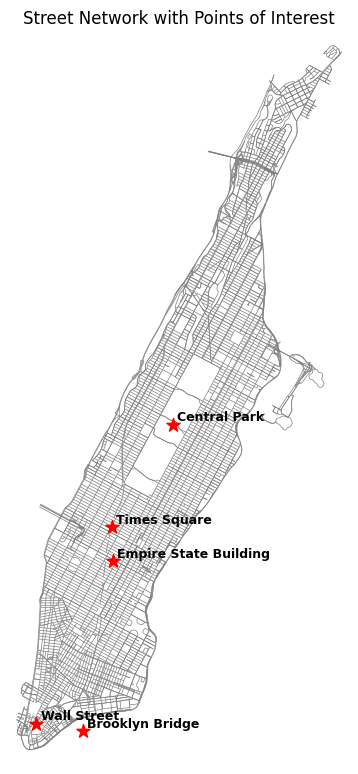

In [12]:
# Function to get coordinates for a place name
def get_coordinates(place_name):
    try:
        location = ox.geocode(place_name)
        return pd.Series({'name': place_name, 'y': location[0], 'x': location[1]})
    except Exception as e:
        print(f"Error geocoding {place_name}: {e}")
        return None

# Define points of interest
poi_names = ["Empire State Building, New York", 
             "Times Square, New York",
             "Central Park, New York",
             "Wall Street, New York",
             "Brooklyn Bridge, New York"]

# Get coordinates for each POI
pois = pd.DataFrame([get_coordinates(place) for place in poi_names if get_coordinates(place) is not None])

# Create GeoDataFrame from POIs
geometry = [Point(xy) for xy in zip(pois['x'], pois['y'])]
pois_gdf = gpd.GeoDataFrame(pois, geometry=geometry, crs="EPSG:4326").to_crs(G_projected.graph['crs'])

# Plot the network and POIs
fig, ax = ox.plot_graph(G_projected, show=False, close=False, 
                       node_size=0, edge_linewidth=0.5, 
                       edge_color='gray', bgcolor='white')
pois_gdf.plot(ax=ax, color='red', markersize=100, marker='*')

# Add labels
for idx, row in pois_gdf.iterrows():
    ax.annotate(row['name'].split(',')[0], 
               (row.geometry.x, row.geometry.y), 
               xytext=(3, 3), textcoords="offset points",
               fontsize=9, fontweight='bold')

plt.title('Street Network with Points of Interest')
plt.tight_layout()
plt.show()

In [13]:
def calculate_distances(pois_gdf, G_projected):
    """Calculate Euclidean and network distances between all pairs of POIs."""
    n = len(pois_gdf)
    euclidean_dist = np.zeros((n, n))
    network_dist = np.zeros((n, n))
    
    # Get the nearest network nodes to each POI
    nodes = ox.distance.nearest_nodes(
        G_projected, 
        X=pois_gdf.geometry.x.values,
        Y=pois_gdf.geometry.y.values
    )
    
    # Calculate distances between all pairs of POIs
    for i in range(n):
        for j in range(i+1, n):
            # Euclidean distance
            euclidean_dist[i, j] = pois_gdf.geometry.iloc[i].distance(pois_gdf.geometry.iloc[j])
            euclidean_dist[j, i] = euclidean_dist[i, j]
            
            # Network distance
            try:
                path_length = nx.shortest_path_length(
                    G_projected, 
                    source=nodes[i], 
                    target=nodes[j], 
                    weight='length'
                )
                network_dist[i, j] = path_length
                network_dist[j, i] = path_length
            except nx.NetworkXNoPath:
                network_dist[i, j] = np.nan
                network_dist[j, i] = np.nan
    
    return euclidean_dist, network_dist

# Calculate distances
euclidean_dist, network_dist = calculate_distances(pois_gdf, G_projected)

# Display results
dist_df = pd.DataFrame(index=pois['name'], columns=pois['name'])
for i in range(len(pois)):
    for j in range(len(pois)):
        if i != j:
            dist_df.iloc[i, j] = f"{euclidean_dist[i,j]/1000:.1f} / {network_dist[i,j]/1000:.1f}"
        else:
            dist_df.iloc[i, j] = "-"

print("Distances (km) - Euclidean / Network")
dist_df

Distances (km) - Euclidean / Network


name,"Empire State Building, New York","Times Square, New York","Central Park, New York","Wall Street, New York","Brooklyn Bridge, New York"
name,,,,,
"Empire State Building, New York",-,1.0 / 1.6,4.2 / 4.8,5.0 / 5.3,4.8 / 6.6
"Times Square, New York",1.0 / 1.6,-,3.3 / 4.3,5.9 / 6.3,5.8 / 8.0
"Central Park, New York",4.2 / 4.8,3.3 / 4.3,-,9.2 / 9.5,9.0 / 10.8
"Wall Street, New York",5.0 / 5.3,5.9 / 6.3,9.2 / 9.5,-,1.3 / 5.9
"Brooklyn Bridge, New York",4.8 / 6.6,5.8 / 8.0,9.0 / 10.8,1.3 / 5.9,-


/tmp/ipykernel_15966/3888858935.py:2: RuntimeWarning: invalid value encountered in divide
  ratio = network_dist / euclidean_dist


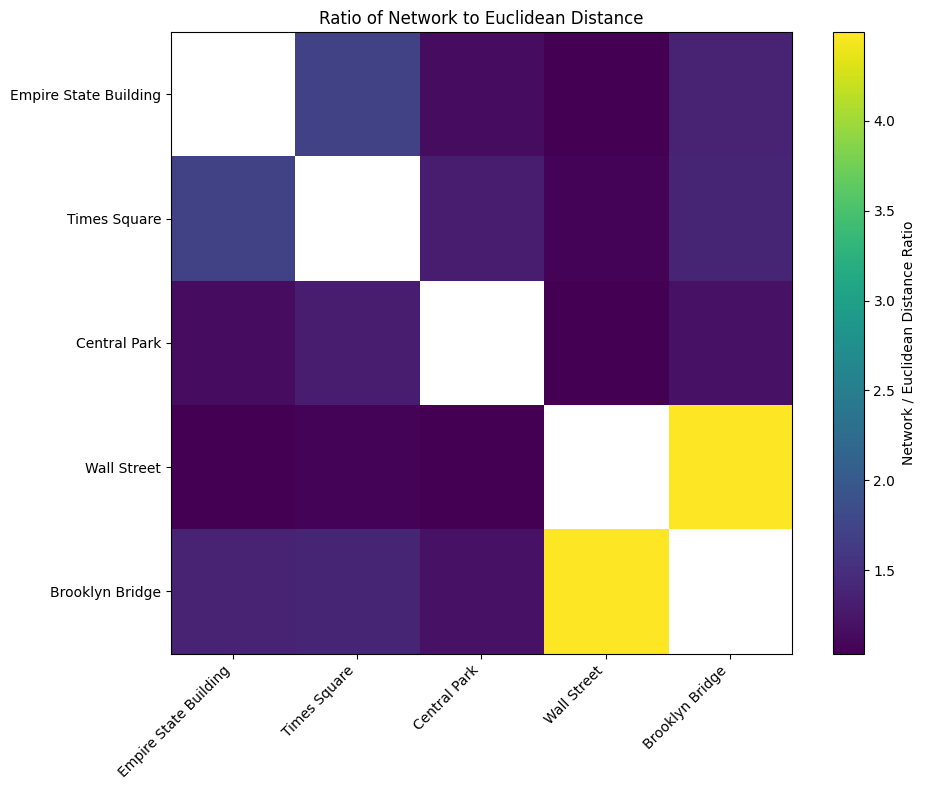

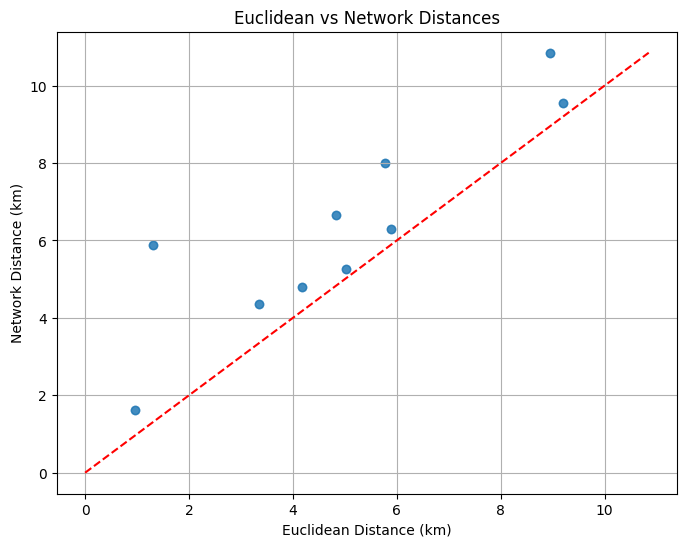

Correlation between Euclidean and Network distances: 0.879
Average ratio (Network/Euclidean): 1.578


In [14]:
# Calculate ratio of network to Euclidean distance
ratio = network_dist / euclidean_dist

# Create heatmap
plt.figure(figsize=(10, 8))
plt.imshow(ratio, cmap='viridis')
plt.colorbar(label='Network / Euclidean Distance Ratio')
plt.xticks(range(len(pois)), [name.split(',')[0] for name in pois['name']], rotation=45, ha='right')
plt.yticks(range(len(pois)), [name.split(',')[0] for name in pois['name']])
plt.title('Ratio of Network to Euclidean Distance')
plt.tight_layout()
plt.show()

# Scatter plot of distances
euclidean_flat = euclidean_dist[~np.eye(len(pois), dtype=bool)].flatten()
network_flat = network_dist[~np.eye(len(pois), dtype=bool)].flatten()

plt.figure(figsize=(8, 6))
plt.scatter(euclidean_flat/1000, network_flat/1000, alpha=0.6)
max_dist = max(max(euclidean_flat), max(network_flat))
plt.plot([0, max_dist/1000], [0, max_dist/1000], 'r--')
plt.xlabel('Euclidean Distance (km)')
plt.ylabel('Network Distance (km)')
plt.title('Euclidean vs Network Distances')
plt.grid(True)
plt.show()

# Calculate statistics
corr, p_value = pearsonr(euclidean_flat, network_flat)
mean_ratio = np.mean(ratio[~np.eye(len(pois), dtype=bool)])

print(f"Correlation between Euclidean and Network distances: {corr:.3f}")
print(f"Average ratio (Network/Euclidean): {mean_ratio:.3f}")

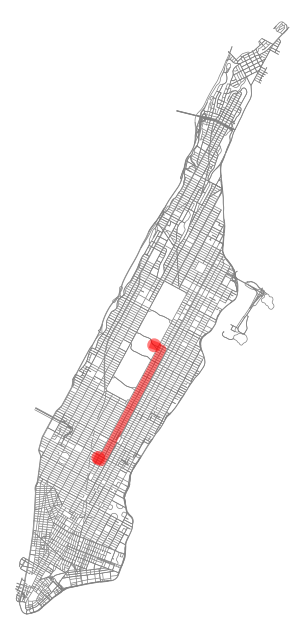

AttributeError: 'Point' object has no attribute 'name'

In [15]:
# Function to plot the shortest path between two points
def plot_shortest_path(G_projected, origin, destination, pois_gdf):
    # Get the nearest nodes
    orig_node = ox.distance.nearest_nodes(G_projected, origin.x, origin.y)
    dest_node = ox.distance.nearest_nodes(G_projected, destination.x, destination.y)
    
    # Get the shortest path
    route = nx.shortest_path(G_projected, orig_node, dest_node, weight='length')
    
    # Plot
    fig, ax = ox.plot_graph_route(G_projected, route, route_linewidth=6, 
                                 node_size=0, bgcolor='white', 
                                 edge_linewidth=0.5, edge_color='gray')
    
    # Add origin and destination
    ax.scatter(origin.x, origin.y, c='red', s=200, marker='*', 
               edgecolor='k', zorder=5, label='Origin')
    ax.scatter(destination.x, destination.y, c='lime', s=200, marker='*', 
               edgecolor='k', zorder=5, label='Destination')
    
    # Add distance labels
    euclidean_dist = origin.distance(destination)
    path_length = nx.shortest_path_length(G_projected, orig_node, dest_node, weight='length')
    ax.set_title(f"Origin: {origin.name}\nDestination: {destination.name}\n"
                f"Euclidean: {euclidean_dist/1000:.1f} km  |  Network: {path_length/1000:.1f} km  |  Ratio: {path_length/euclidean_dist:.2f}")
    plt.legend()
    plt.show()

# Plot example routes
plot_shortest_path(G_projected, 
                  pois_gdf.iloc[0].geometry,  # Empire State Building
                  pois_gdf.iloc[2].geometry,  # Central Park
                  pois_gdf)

plot_shortest_path(G_projected,
                  pois_gdf.iloc[3].geometry,  # Wall Street
                  pois_gdf.iloc[4].geometry,  # Brooklyn Bridge
                  pois_gdf)

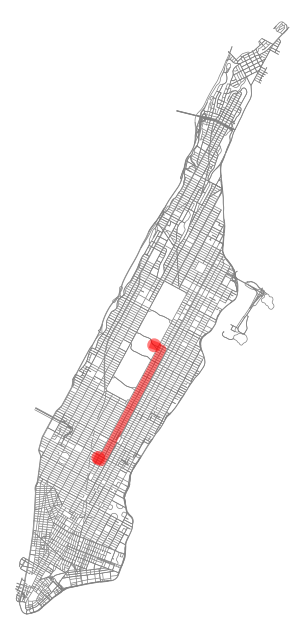

/tmp/ipykernel_15966/907951614.py:25: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


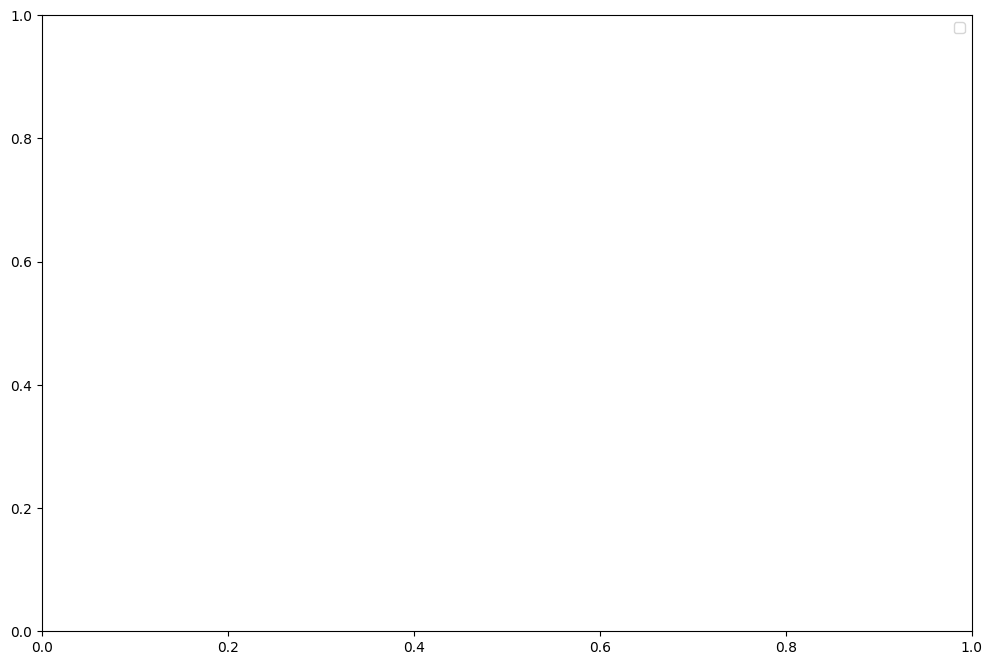

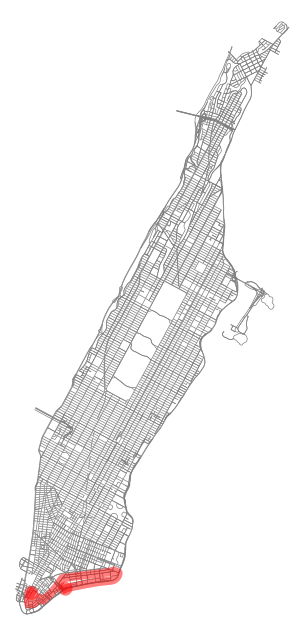

/tmp/ipykernel_15966/907951614.py:25: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


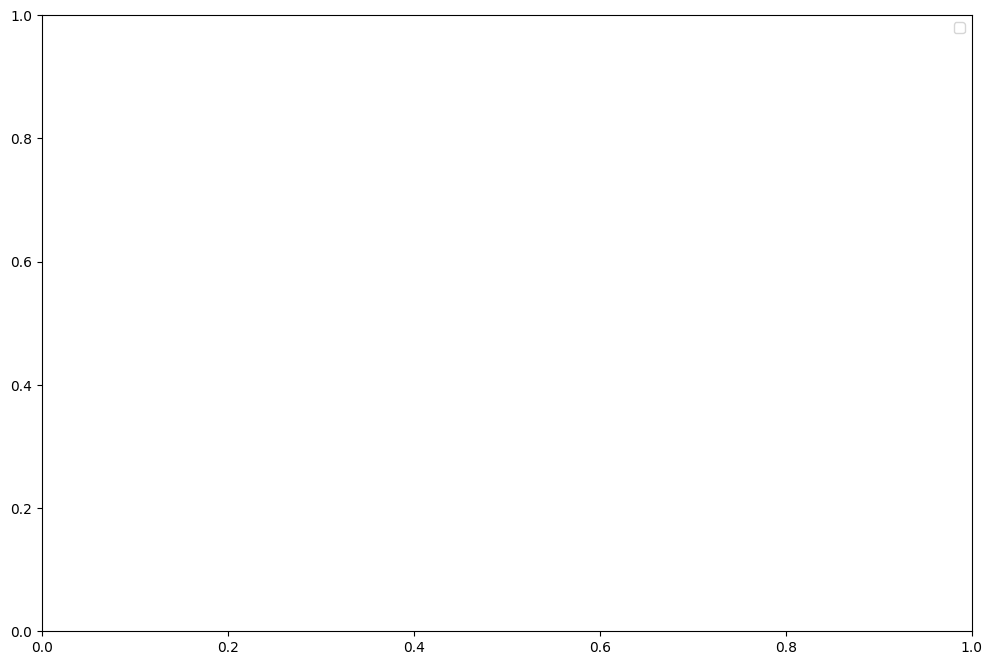

In [16]:
def plot_shortest_path(G_projected, origin_geom, dest_geom, origin_name, dest_name, pois_gdf):
    # Get the nearest nodes
    orig_node = ox.distance.nearest_nodes(G_projected, origin_geom.x, origin_geom.y)
    dest_node = ox.distance.nearest_nodes(G_projected, dest_geom.x, dest_geom.y)
    
    # Get the shortest path
    route = nx.shortest_path(G_projected, orig_node, dest_node, weight='length')
    
    # Plot
    fig, ax = ox.plot_graph_route(G_projected, route, route_linewidth=6, 
                                 node_size=0, bgcolor='white', 
                                 edge_linewidth=0.5, edge_color='gray')
    
    # Add origin and destination
    ax.scatter(origin_geom.x, origin_geom.y, c='red', s=200, marker='*', 
               edgecolor='k', zorder=5, label='Origin')
    ax.scatter(dest_geom.x, dest_geom.y, c='lime', s=200, marker='*', 
               edgecolor='k', zorder=5, label='Destination')
    
    # Add distance labels
    euclidean_dist = origin_geom.distance(dest_geom)
    path_length = nx.shortest_path_length(G_projected, orig_node, dest_node, weight='length')
    ax.set_title(f"Origin: {origin_name}\nDestination: {dest_name}\n"
                f"Euclidean: {euclidean_dist/1000:.1f} km  |  Network: {path_length/1000:.1f} km  |  Ratio: {path_length/euclidean_dist:.2f}")
    plt.legend()
    plt.show()

# Plot example routes
plot_shortest_path(G_projected, 
                  pois_gdf.iloc[0].geometry,  # Origin geometry
                  pois_gdf.iloc[2].geometry,  # Destination geometry
                  pois_gdf.iloc[0]['name'],   # Origin name
                  pois_gdf.iloc[2]['name'],   # Destination name
                  pois_gdf)

plot_shortest_path(G_projected,
                  pois_gdf.iloc[3].geometry,  # Origin geometry
                  pois_gdf.iloc[4].geometry,  # Destination geometry
                  pois_gdf.iloc[3]['name'],   # Origin name
                  pois_gdf.iloc[4]['name'],   # Destination name
                  pois_gdf)